Лабораторна робота №1

1. Імпортуємо необхідні бібліотеки

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

2. Зчитуємо датасет про успішність студентів.

In [58]:
df = pd.read_csv("Student_Performance.csv")
print(df.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


3. Проводимо розвідковий аналіз: виводимо детальну інформацію про датасет, перевіряємо на пропущені значення – їх немає

In [59]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

4. Категоріальна змінна Extracurricular Activities закодована у числовий формат (0/1)

In [60]:
df["Extracurricular Activities"] = (
    df["Extracurricular Activities"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"no": 0, "yes": 1})
)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


5.	Будуємо мапу тепла для цих даних, що показує кореляцію між ознаками

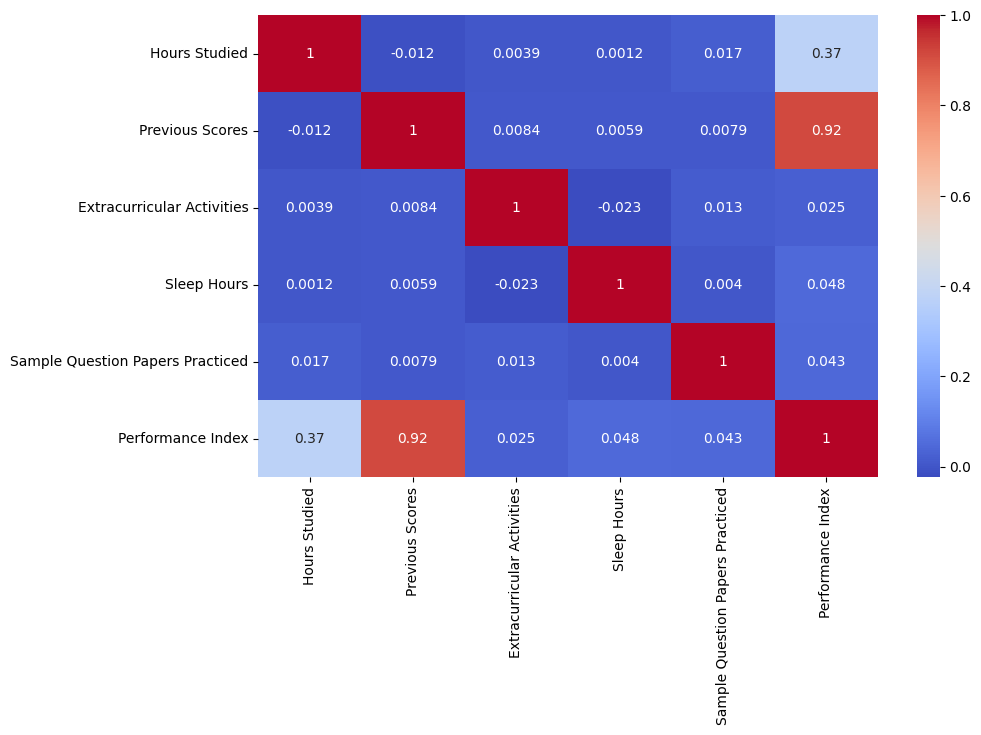

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

6.	Розділяємо дані спочатку на цільові дані (Y) та ознаки X

In [62]:
y = df["Performance Index"] 
X = df.drop(columns=["Performance Index"])

7. Розділяємо дані на тренувальні та тестові у пропорціях 80/20

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.	Масштабуємо дані за допомогою Standard Scaler. Додаємо стовпчик додаткових одиниць для intercept.

In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

9. Починаємо реалізацію градієнтного спуску. Ініціалізуємо вектор ваг β нулями.

In [65]:
b = np.zeros(X_train_final.shape[1])

10.	Програмуємо функцію для обчислення MSE (середньої квадратичної похибки)

In [66]:
def compute_cost(X, y, b):
    predictions = X.dot(b)
    errors = predictions - y
    mse = (1 / len(y)) * np.sum(errors ** 2)
    return mse

11. Програмуємо функцію для градієнтного спуску. Вона поступово змінює коефіцієнти моделі так, щоб мінімізувати різницю між прогнозованими та фактичними значеннями. На кожній ітерації обчислюється похибка, градієнт функції втрат і виконується оновлення коефіцієнтів. Параметр learning_rate визначає розмір кроку оновлення, а epochs — кількість ітерацій алгоритму. Функція також зберігає історію значень функції втрат, що дозволяє відслідковувати збіжність алгоритму.

In [67]:
def gradient_descent(X, y, b, learning_rate, epochs):
    cost_history = []
    m = len(y)

    for _ in range(epochs):
        predictions = X.dot(b)
        errors = predictions - y
        gradient = (1/m) * X.T.dot(errors)
        b -= learning_rate * gradient
        cost_history.append(compute_cost(X, y, b))
    return b, cost_history

12.	Запускаємо навчання. Задаємо параметри перед тим.

In [68]:
learning_rate = 0.01
epochs = 1000
b_final, cost_history = gradient_descent(X_train_final, y_train, b, learning_rate, epochs)

13.	Візуалізуємо зменшення похибки – збіжність градієнтного спуску. Крива функції втрат стрімко спадала на перших ітераціях і поступово вирівнювалась, демонструючи стабільну збіжність.

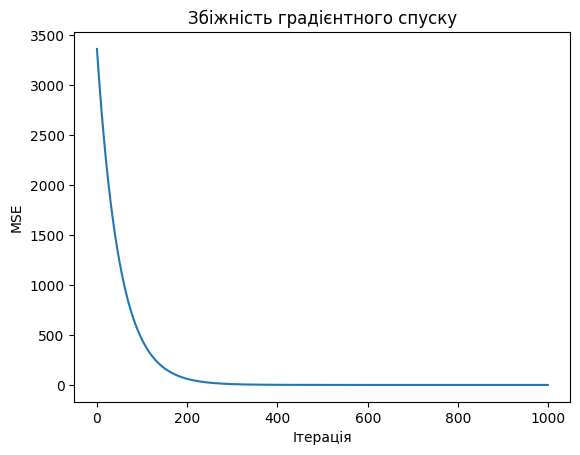

In [69]:
plt.plot(range(epochs), cost_history)
plt.xlabel("Ітерація")
plt.ylabel("MSE")
plt.title("Збіжність градієнтного спуску")
plt.show()

14.	Проведемо оцінку якості моделі на тестових даних. Прогнозування:

In [70]:
y_pred = X_test_final.dot(b_final)

15. Розраховуємо метрики – MSE та R2.

In [71]:
mse_test = np.mean((y_test - y_pred) ** 2)
r2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
print("MSE:", mse_test)
print("R²:", r2)

MSE: 4.082454883009034
R²: 0.9889837591777187


16. Перевіряємо припущення. Будуємо графік залишків від передбачених значень. Точки утворюють хаотичну хмару навколо нульової осі, без трендів

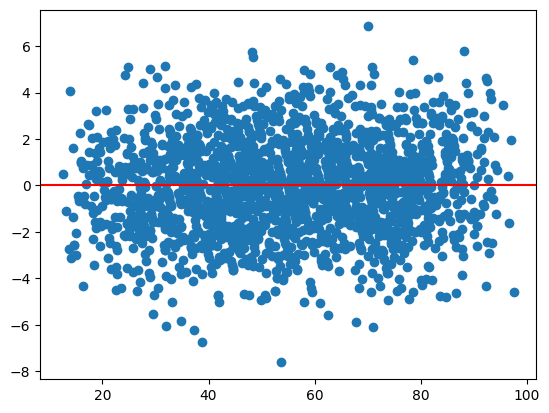

In [72]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.show()

17.	Розраховуємо мультиколінеарність (VIF)

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
print(vif)

[1.0003869791709703, 1.0002433681390286, 1.0004283022463083, 1.0004613525942865, 1.0003204086793536]


18. Перевіримо нормальність залишків. Побудуємо Q-Q plot. Залишки розташовані майже на діагоналі, відхилення мінімальні.

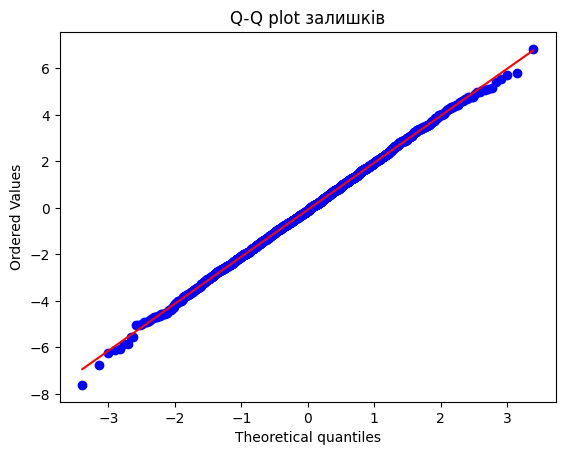

In [74]:
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot залишків")
plt.show()

19. Виконаємо статистичний тест (Shapiro-Wilk тест)

In [75]:
from scipy.stats import shapiro
stat, p = shapiro(residuals)
print("Shapiro-Wilk test: stat=%.3f, p=%.3f" % (stat, p))
if p > 0.05:
    print("Залишки можна вважати нормальними")
else:
    print("Залишки відхиляються від нормальності")

Shapiro-Wilk test: stat=1.000, p=0.975
Залишки можна вважати нормальними


20.	Перевіряємо гомоскедатичність (постійну дисперсію залишків)

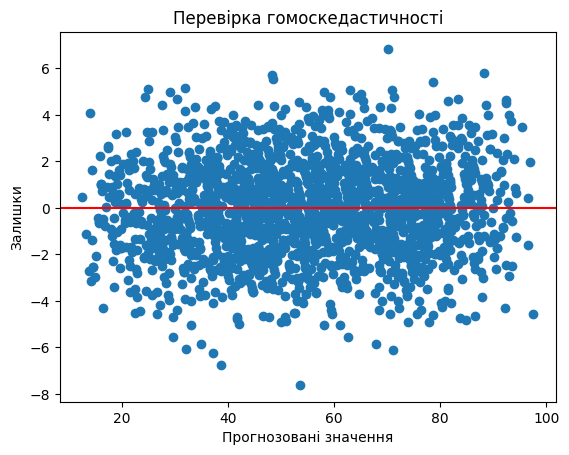

In [76]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Прогнозовані значення")
plt.ylabel("Залишки")
plt.title("Перевірка гомоскедастичності")
plt.show()

21.	Перевіряємо залишки на автокореляцію

In [77]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)
if 1.5 < dw < 2.5:
    print("Відсутня автокореляція залишків")
elif dw <= 1.5:
        print("Позитивна автокореляція залишків")
else:
    print("Негативна автокореляція залишків")

Durbin-Watson: 2.0473842142537704
Відсутня автокореляція залишків


22.	Перевіряємо на викиди та впливові спостереження

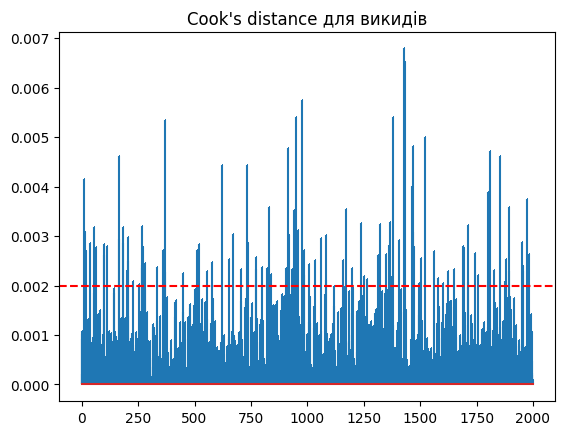

Індекси можливих впливових спостережень: [  11   16   19   36   53   64   98   99  113  163  165  183  185  201
  204  206  226  253  265  267  268  272  282  333  360  367  369  448
  510  518  557  576  621  653  672  704  731  737  773  774  801  822
  828  833  838  906  913  914  917  933  940  951  960  976  984  987
 1009 1034 1062 1081 1082 1157 1171 1198 1237 1249 1266 1314 1322 1350
 1360 1368 1376 1381 1405 1429 1434 1464 1468 1470 1474 1493 1504 1523
 1562 1578 1602 1622 1648 1692 1693 1711 1714 1742 1756 1801 1810 1829
 1852 1875 1880 1892 1895 1950 1955 1958 1975 1983]


In [78]:
import statsmodels.api as sm
X_with_const = sm.add_constant(X_test_final)
model = sm.OLS(y_test, X_with_const).fit()
influence = model.get_influence()
cooks_d, pvals = influence.cooks_distance

plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4/len(cooks_d), color="red", linestyle="--")
plt.title("Cook's distance для викидів")
plt.show()

threshold = 4 / len(cooks_d)
outliers = np.where(cooks_d > threshold)[0]
print("Індекси можливих впливових спостережень:", outliers)

РЕЗУЛЬТАТИ

Результати моделі:
•	Коефіцієнти регресії: усі близькі до 1.0, що свідчить про пропорційний вплив кожного фактору.
•	MSE = 4.08 → середня похибка передбачення є малою.
•	R² = 0.989 → модель добре узгоджується з даними.

Перевірка припущень МНК
1.	Лінійність зв’язку
o	Побудовано графік залишків vs. прогнозів.
o	Хмара точок рівномірно розподілена навколо нуля, явних U-подібних чи S-подібних трендів немає.
	→ Припущення виконується.
2.	Відсутність мультиколінеарності
o	Розраховані VIF для ознак: усі < 5.
	→ Сильних кореляцій між предикторами немає.
3.	Нормальність залишків
o	Q-Q plot: точки лягли майже на пряму.
o	Shapiro-Wilk test: p=0.975 > 0.05 → залишки мають нормальний розподіл.
	→ Припущення виконується.
4.	Гомоскедастичність
o	Графік залишків показує рівномірний розкид.
o	Ознак «воронки» чи зростання дисперсії немає.
	→ Припущення виконується.
5.	Відсутність автокореляції залишків
o	Durbin-Watson = 2.05 (значення близьке до 2).
	→ Автокореляція відсутня.
6.	Відсутність викидів та впливових спостережень
o	Виявлені окремі впливові точки (наприклад, індекси 11, 16, 19…), але їх відсоток малий.
o	Cook’s Distance показав, що жодне спостереження критично не домінує.
	→ Припущення загалом виконується